In [1]:
import pandas as pd

df = pd.read_csv('Sentiment_dataset.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())
print("\nData types:\n", df.dtypes)

Shape: (732, 15)

Columns: ['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']

First 5 rows:


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19



Data types:
 Unnamed: 0.1      int64
Unnamed: 0        int64
Text             object
Sentiment        object
Timestamp        object
User             object
Platform         object
Hashtags         object
Retweets        float64
Likes           float64
Country          object
Year              int64
Month             int64
Day               int64
Hour              int64
dtype: object


In [2]:
# install required libraries
# this only needs to run ONCE
import subprocess
subprocess.run(['pip', 'install', 'textblob', 'wordcloud'], 
               capture_output=True)

# download TextBlob's language data
# TextBlob needs this to analyze text properly
import subprocess
subprocess.run(['python', '-m', 'textblob.download_corpora'], 
               capture_output=True)

print("✅ Installation complete")

✅ Installation complete


In [3]:
# ============================================================
# CODVEDA INTERNSHIP | Level 3 | Task 3: NLP Sentiment Analysis
# Dataset: sentiment.csv (732 social media posts)
# Goal: Preprocess text, compute sentiment, visualize results
# ============================================================

# TextBlob and wordcloud may need installing
# run this once — comment out after first run
# import subprocess
# subprocess.run(['pip', 'install', 'textblob', 'wordcloud'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TextBlob — simple NLP library for sentiment analysis
# .sentiment returns polarity (-1 to +1) and subjectivity (0 to 1)
from textblob import TextBlob

# NLTK — Natural Language Toolkit
# provides tokenization, stopwords, stemming tools
import nltk

# download required NLTK data files
# punkt    → tokenizer rules
# stopwords → list of common meaningless words
# averaged_perceptron_tagger → part of speech tagger
nltk.download('punkt',      quiet=True)
nltk.download('stopwords',  quiet=True)
nltk.download('wordnet',    quiet=True)

from nltk.corpus   import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem     import WordNetLemmatizer

# WordCloud — creates visual word frequency maps
from wordcloud import WordCloud

import re        # regular expressions — for text cleaning
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

import os
os.makedirs('plots', exist_ok=True)

print("✅ All imports successful")

✅ All imports successful


In [5]:
# ============================================================
# LOAD AND CLEAN DATA
# ============================================================

df = pd.read_csv('Sentiment_dataset.csv')

print(f"Raw shape: {df.shape}")

# ── DROP UNNECESSARY COLUMNS ──────────────────────────────
# Unnamed columns are leftover index columns from saving/loading
# they carry no information — just clutter
df = df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'])

print(f"After dropping index columns: {df.shape}")

# ── CHECK MISSING VALUES ──────────────────────────────────
print(f"\nMissing values per column:")
print(df.isnull().sum())

# ── CHECK SENTIMENT DISTRIBUTION ──────────────────────────
print(f"\nSentiment distribution (pre-labeled):")
print(df['Sentiment'].value_counts())
print(f"\nSentiment percentages:")
print((df['Sentiment'].value_counts() / len(df) * 100).round(1))

# ── LOOK AT SAMPLE TEXTS ──────────────────────────────────
print(f"\nSample texts by sentiment:")
for sentiment in ['Positive', 'Negative', 'Neutral']:
    sample = df[df['Sentiment']==sentiment]['Text'].iloc[0]
    print(f"\n  {sentiment}: {sample[:100]}")

Raw shape: (732, 15)
After dropping index columns: (732, 13)

Missing values per column:
Text         0
Sentiment    0
Timestamp    0
User         0
Platform     0
Hashtags     0
Retweets     0
Likes        0
Country      0
Year         0
Month        0
Day          0
Hour         0
dtype: int64

Sentiment distribution (pre-labeled):
Sentiment
Positive           44
Joy                42
Excitement         32
Neutral            14
Contentment        14
                   ..
Adrenaline          1
Harmony             1
ArtisticBurst       1
Radiance            1
Elegance            1
Name: count, Length: 279, dtype: int64

Sentiment percentages:
Sentiment
Positive           6.0
Joy                5.7
Excitement         4.4
Neutral            1.9
Contentment        1.9
                  ... 
Adrenaline         0.1
Harmony            0.1
ArtisticBurst      0.1
Radiance           0.1
Elegance           0.1
Name: count, Length: 279, dtype: float64

Sample texts by sentiment:


IndexError: single positional indexer is out-of-bounds

In [6]:
# ============================================================
# TEXT PREPROCESSING — the most important NLP step
# ============================================================

# initialize the lemmatizer
# lemmatization converts words to their base form
# "running" → "run", "better" → "good", "studies" → "study"
# more accurate than stemming (which just chops endings)
lemmatizer = WordNetLemmatizer()

# get English stopwords — words that carry no sentiment meaning
# examples: "the", "is", "at", "which", "on", "a", "an"
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Full text preprocessing pipeline.
    Takes raw text, returns cleaned list of meaningful words.

    Steps:
    1. Convert to lowercase — "Happy" and "happy" are the same
    2. Remove URLs — http://... adds no sentiment
    3. Remove special characters — keep only letters and spaces
    4. Remove extra whitespace — clean up gaps left by removal
    5. Tokenize — split sentence into individual words
    6. Remove stopwords — drop meaningless common words
    7. Lemmatize — convert words to base form
    8. Remove short words — single letters add no meaning
    """

    # step 1: lowercase
    # "AMAZING" and "amazing" should be treated identically
    text = text.lower()

    # step 2: remove URLs
    # re.sub replaces pattern matches with empty string
    # r'http\S+' matches "http" followed by non-whitespace chars
    text = re.sub(r'http\S+', '', text)

    # step 3: remove special characters and numbers
    # [^a-z\s] means "anything NOT a letter or space"
    # keeps only letters and spaces
    text = re.sub(r'[^a-z\s]', '', text)

    # step 4: remove extra whitespace
    # \s+ matches one or more whitespace characters
    # replaces them with a single space
    text = re.sub(r'\s+', ' ', text).strip()

    # step 5: tokenize — split into individual words
    # "i love this product" → ["i", "love", "this", "product"]
    tokens = word_tokenize(text)

    # step 6 + 7 + 8: remove stopwords, lemmatize, remove short words
    # all in one list comprehension for efficiency
    tokens = [
        lemmatizer.lemmatize(word)  # step 7: lemmatize
        for word in tokens          # loop through tokens
        if word not in stop_words   # step 6: skip stopwords
        and len(word) > 2           # step 8: skip short words
    ]

    return tokens

# apply preprocessing to every text in the dataset
# this may take a few seconds for 732 posts
df['tokens']       = df['Text'].apply(preprocess_text)

# join tokens back into a string for TextBlob and WordCloud
df['clean_text']   = df['tokens'].apply(lambda x: ' '.join(x))

print("✅ Text preprocessing complete")
print(f"\nExample — original vs processed:")
print(f"\nOriginal : {df['Text'].iloc[0]}")
print(f"Tokens   : {df['tokens'].iloc[0]}")
print(f"Clean    : {df['clean_text'].iloc[0]}")

print(f"\nAnother example:")
print(f"Original : {df['Text'].iloc[1]}")
print(f"Tokens   : {df['tokens'].iloc[1]}")
print(f"Clean    : {df['clean_text'].iloc[1]}")

✅ Text preprocessing complete

Example — original vs processed:

Original :  Enjoying a beautiful day at the park!              
Tokens   : ['enjoying', 'beautiful', 'day', 'park']
Clean    : enjoying beautiful day park

Another example:
Original :  Traffic was terrible this morning.                 
Tokens   : ['traffic', 'terrible', 'morning']
Clean    : traffic terrible morning


In [9]:
# ============================================================
# COMPUTE SENTIMENT WITH TEXTBLOB
# ============================================================

def get_sentiment_scores(text):
    """
    Uses TextBlob to compute sentiment polarity and subjectivity.

    TextBlob.sentiment returns two values:
    polarity    → float from -1.0 to +1.0
                  -1.0 = very negative ("terrible", "awful")
                   0.0 = neutral ("okay", "fine")
                  +1.0 = very positive ("amazing", "excellent")

    subjectivity → float from 0.0 to 1.0
                   0.0 = objective fact ("it rained today")
                   1.0 = personal opinion ("I loved every moment")
    """
    analysis = TextBlob(text)
    return pd.Series({
        'polarity'      : analysis.sentiment.polarity,
        'subjectivity'  : analysis.sentiment.subjectivity
    })

# apply to every row — creates two new columns
# this runs TextBlob on all 732 posts
sentiment_scores        = df['Text'].apply(get_sentiment_scores)
df['polarity']          = sentiment_scores['polarity']
df['subjectivity']      = sentiment_scores['subjectivity']

# convert polarity score to sentiment label
# using thresholds:
# polarity > 0.05  → Positive
# polarity < -0.05 → Negative
# between          → Neutral
# (0.05 threshold avoids classifying near-zero as positive/negative)
def polarity_to_label(polarity):
    if polarity > 0.05:
        return 'Positive'
    elif polarity < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['computed_sentiment'] = df['polarity'].apply(polarity_to_label)

print("✅ TextBlob sentiment analysis complete")
print(f"\nPOLARITY STATISTICS:")
print(df['polarity'].describe().round(3))

print(f"\nSUBJECTIVITY STATISTICS:")
print(df['subjectivity'].describe().round(3))

print(f"\nCOMPUTED SENTIMENT DISTRIBUTION:")
print(df['computed_sentiment'].value_counts())

print(f"\nPRE-LABELED SENTIMENT DISTRIBUTION:")
print(df['Sentiment'].value_counts())

print(f"\nSAMPLE — TEXT, POLARITY AND LABELS:")
sample_cols = ['Text', 'polarity', 'Sentiment', 'computed_sentiment']
display(df[sample_cols].head(10))

✅ TextBlob sentiment analysis complete

POLARITY STATISTICS:
count    732.000
mean       0.098
std        0.313
min       -1.000
25%        0.000
50%        0.000
75%        0.250
max        1.000
Name: polarity, dtype: float64

SUBJECTIVITY STATISTICS:
count    732.000
mean       0.345
std        0.344
min        0.000
25%        0.000
50%        0.300
75%        0.600
max        1.000
Name: subjectivity, dtype: float64

COMPUTED SENTIMENT DISTRIBUTION:
computed_sentiment
Neutral     342
Positive    271
Negative    119
Name: count, dtype: int64

PRE-LABELED SENTIMENT DISTRIBUTION:
Sentiment
Positive           44
Joy                42
Excitement         32
Neutral            14
Contentment        14
                   ..
Adrenaline          1
Harmony             1
ArtisticBurst       1
Radiance            1
Elegance            1
Name: count, Length: 279, dtype: int64

SAMPLE — TEXT, POLARITY AND LABELS:


,Text,polarity,Sentiment,computed_sentiment
0,Enjoying a beautiful day at the park! ...,0.750000,Positive,Positive
1,Traffic was terrible this morning. ...,-1.000000,Negative,Negative
2,Just finished an amazing workout! 💪 ...,0.750000,Positive,Positive
3,Excited about the upcoming weekend getaway! ...,0.468750,Positive,Positive
4,Trying out a new recipe for dinner tonight. ...,0.136364,Neutral,Positive
5,Feeling grateful for the little things in lif...,-0.187500,Positive,Negative
6,Rainy days call for cozy blankets and hot coc...,0.025000,Positive,Neutral
7,The new movie release is a must-watch! ...,0.170455,Positive,Positive
8,Political discussions heating up on the timel...,0.000000,Negative,Neutral
9,Missing summer vibes and beach days. ...,-0.200000,Neutral,Negative


After standardization:
  Pre-labeled unique  : ['Acceptance', 'Accomplishment', 'Admiration', 'Adoration', 'Adrenaline', 'Adventure', 'Affection', 'Amazement', 'Ambivalence', 'Amusement', 'Anger', 'Anticipation', 'Anxiety', 'Appreciation', 'Apprehensive', 'Arousal', 'Artisticburst', 'Awe', 'Bad', 'Betrayal', 'Bitter', 'Bitterness', 'Bittersweet', 'Blessed', 'Boredom', 'Breakthrough', 'Calmness', 'Captivation', 'Celebration', 'Celestial wonder', 'Challenge', 'Charm', 'Colorful', 'Compassion', 'Compassionate', 'Confidence', 'Confident', 'Confusion', 'Connection', 'Contemplation', 'Contentment', 'Coziness', 'Creative inspiration', 'Creativity', 'Culinary adventure', 'Culinaryodyssey', 'Curiosity', 'Darkness', 'Dazzle', 'Desolation', 'Despair', 'Desperation', 'Determination', 'Devastated', 'Disappointed', 'Disappointment', 'Disgust', 'Dismissive', 'Dreamchaser', 'Ecstasy', 'Elation', 'Elegance', 'Embarrassed', 'Emotion', 'Emotionalstorm', 'Empathetic', 'Empowerment', 'Enchantment', 'Energy

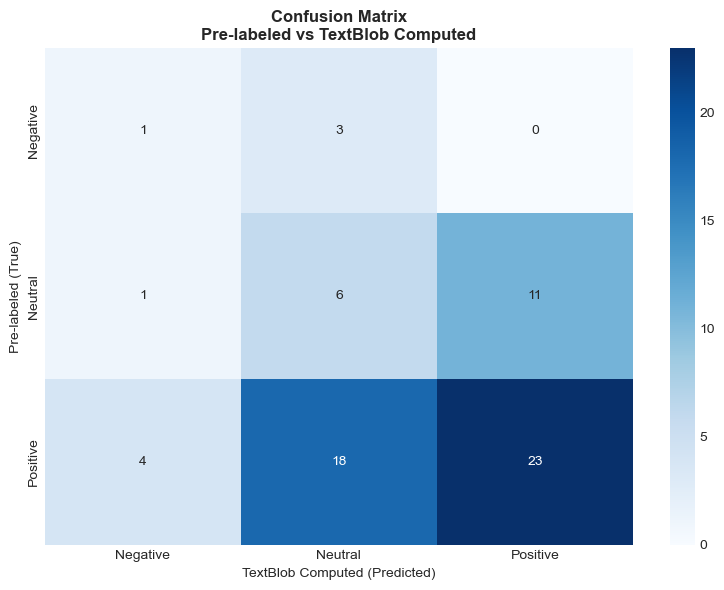

✅ Saved: plots/sentiment_confusion.png


In [15]:
# ============================================================
# COMPARE PRE-LABELED vs TEXTBLOB COMPUTED
# ============================================================

# STEP 1 — standardize BOTH columns to same format
# .str.strip() removes spaces
# .str.capitalize() makes First letter uppercase, rest lowercase
# this handles: 'positive', 'POSITIVE', ' Positive ' → 'Positive'
df['Sentiment']          = df['Sentiment'].str.strip().str.capitalize()
df['computed_sentiment'] = df['computed_sentiment'].str.strip().str.capitalize()

print("After standardization:")
print(f"  Pre-labeled unique  : {sorted(df['Sentiment'].unique())}")
print(f"  Computed unique     : {sorted(df['computed_sentiment'].unique())}")

# STEP 2 — filter to only standard three categories
valid_mask = df['Sentiment'].isin(['Positive', 'Negative', 'Neutral'])
df_valid   = df[valid_mask].copy()
print(f"\nValid rows for comparison: {len(df_valid)}")

# STEP 3 — check both distributions
print("\nPre-labeled distribution:")
print(df_valid['Sentiment'].value_counts())
print("\nComputed distribution:")
print(df_valid['computed_sentiment'].value_counts())

# STEP 4 — find common labels safely
pre_labels      = set(df_valid['Sentiment'].unique())
computed_labels = set(df_valid['computed_sentiment'].unique())
actual_labels   = sorted(list(pre_labels & computed_labels))

print(f"\nLabels in pre-labeled  : {sorted(pre_labels)}")
print(f"Labels in computed     : {sorted(computed_labels)}")
print(f"Common labels          : {actual_labels}")

# STEP 5 — only proceed if common labels exist
if len(actual_labels) == 0:
    print("\n⚠️  No common labels found!")
    print("   Pre-labeled and computed have completely different values")
    print("   Check the diagnostic output above")
else:
    # filter to only rows where both columns use common labels
    mask = (
        df_valid['Sentiment'].isin(actual_labels) &
        df_valid['computed_sentiment'].isin(actual_labels)
    )
    df_compare = df_valid[mask].copy()
    print(f"\nRows available for comparison: {len(df_compare)}")

    # classification report
    print("\nCLASSIFICATION REPORT:")
    print(classification_report(
        df_compare['Sentiment'],
        df_compare['computed_sentiment'],
        labels=actual_labels,
        zero_division=0
    ))

    # confusion matrix
    cm = confusion_matrix(
        df_compare['Sentiment'],
        df_compare['computed_sentiment'],
        labels=actual_labels
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=actual_labels,
        yticklabels=actual_labels
    )
    ax.set_title(
        'Confusion Matrix\nPre-labeled vs TextBlob Computed',
        fontweight='bold'
    )
    ax.set_ylabel('Pre-labeled (True)')
    ax.set_xlabel('TextBlob Computed (Predicted)')
    plt.tight_layout()
    plt.savefig(
        'plots/sentiment_confusion.png',
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()
    print("✅ Saved: plots/sentiment_confusion.png")

MAPPED SENTIMENT DISTRIBUTION (all 732 rows):
mapped_sentiment
Positive    482
Negative    183
Neutral      67
Name: count, dtype: int64

Percentages:
mapped_sentiment
Positive    65.8
Negative    25.0
Neutral      9.2
Name: count, dtype: float64

COMPUTED SENTIMENT DISTRIBUTION:
computed_sentiment
Neutral     342
Positive    271
Negative    119
Name: count, dtype: int64

CLASSIFICATION REPORT (all 732 rows):
              precision    recall  f1-score   support

    Positive       0.86      0.48      0.62       482
     Neutral       0.11      0.57      0.19        67
    Negative       0.60      0.39      0.47       183

    accuracy                           0.47       732
   macro avg       0.52      0.48      0.42       732
weighted avg       0.73      0.47      0.54       732



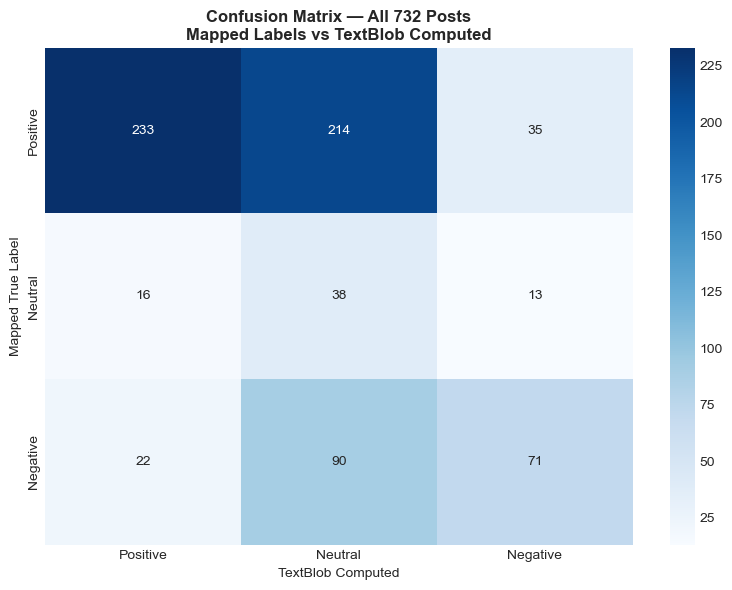

✅ Saved: plots/sentiment_confusion.png


In [16]:
# ============================================================
# MAP EMOTION LABELS TO SENTIMENT CATEGORIES
# ============================================================

# your dataset has 180+ specific emotions
# we map them all to Positive / Neutral / Negative
# based on their emotional valence

positive_emotions = {
    'Acceptance', 'Accomplishment', 'Admiration', 'Adoration',
    'Adventure', 'Affection', 'Amazement', 'Amusement',
    'Anticipation', 'Appreciation', 'Artisticburst', 'Awe',
    'Blessed', 'Breakthrough', 'Calmness', 'Captivation',
    'Celebration', 'Charm', 'Colorful', 'Compassion',
    'Compassionate', 'Confidence', 'Confident', 'Connection',
    'Contentment', 'Coziness', 'Creative inspiration',
    'Creativity', 'Culinary adventure', 'Culinaryodyssey',
    'Curiosity', 'Dazzle', 'Determination', 'Dreamchaser',
    'Ecstasy', 'Elation', 'Elegance', 'Empowerment',
    'Enchantment', 'Energy', 'Engagement', 'Enjoyment',
    'Enthusiasm', 'Euphoria', 'Excitement', 'Exploration',
    'Festivejoy', 'Free-spirited', 'Freedom', 'Friendship',
    'Fulfillment', 'Grandeur', 'Grateful', 'Gratitude',
    'Happiness', 'Happy', 'Harmony', 'Heartwarming', 'Hope',
    'Hopeful', 'Hypnotic', 'Iconic', 'Imagination', 'Immersion',
    'Innerjourney', 'Inspiration', 'Inspired', 'Intrigue',
    'Joy', 'Joy in baking', 'Joyfulreunion', 'Kind', 'Kindness',
    'Love', 'Marvel', 'Melodic', 'Mesmerizing', 'Mindfulness',
    'Motivation', "Nature's beauty", 'Nostalgia', 'Optimism',
    'Overjoyed', 'Playful', 'Playfuljoy', 'Positive',
    'Positivity', 'Pride', 'Proud', 'Radiance', 'Rejuvenation',
    'Relief', 'Renewed effort', 'Resilience', 'Reverence',
    'Romance', 'Runway creativity', 'Satisfaction', 'Serenity',
    'Solace', 'Spark', 'Success', 'Surprise', 'Tenderness',
    'Thrill', 'Thrilling journey', 'Touched', 'Tranquility',
    'Triumph', 'Vibrancy', 'Whimsy', 'Wonder', 'Wonderment',
    'Zest', 'Celebration', 'Adrenaline', 'Arousal'
}

negative_emotions = {
    'Anger', 'Anxiety', 'Apprehensive', 'Bad', 'Betrayal',
    'Bitter', 'Bitterness', 'Darkness', 'Desolation', 'Despair',
    'Desperation', 'Devastated', 'Disappointed', 'Disappointment',
    'Disgust', 'Dismissive', 'Embarrassed', 'Emotionalstorm',
    'Envious', 'Envy', 'Exhaustion', 'Fear', 'Fearful',
    'Frustrated', 'Frustration', 'Grief', 'Hate', 'Heartache',
    'Heartbreak', 'Helplessness', 'Intimidation', 'Isolation',
    'Jealous', 'Jealousy', 'Loneliness', 'Loss', 'Lostlove',
    'Melancholy', 'Miscalculation', 'Negative', 'Numbness',
    'Obstacle', 'Overwhelmed', 'Pressure', 'Regret', 'Resentment',
    'Ruins', 'Sad', 'Sadness', 'Shame', 'Solitude', 'Sorrow',
    'Suffering', 'Suspense'
}

neutral_emotions = {
    'Ambivalence', 'Boredom', 'Celestial wonder', 'Challenge',
    'Compassionate', 'Contemplation', 'Confusion', 'Empathetic',
    'Emotion', 'Envisioning history', 'Indifference', 'Journey',
    'Mischievous', 'Neutral', "Ocean's freedom", 'Pensive',
    'Reflection', 'Sympathy', 'Whispers of the past',
    'Winter magic', 'Yearning', 'Bittersweet'
}

def map_to_sentiment(emotion):
    # .capitalize() standardizes the input
    emotion = str(emotion).strip().capitalize()
    if emotion in positive_emotions:
        return 'Positive'
    elif emotion in negative_emotions:
        return 'Negative'
    elif emotion in neutral_emotions:
        return 'Neutral'
    else:
        # default unknown emotions to neutral
        return 'Neutral'

# apply mapping to ALL 732 rows
df['mapped_sentiment'] = df['Sentiment'].apply(map_to_sentiment)

print("MAPPED SENTIMENT DISTRIBUTION (all 732 rows):")
print(df['mapped_sentiment'].value_counts())
print(f"\nPercentages:")
print((df['mapped_sentiment'].value_counts() /
       len(df) * 100).round(1))

print(f"\nCOMPUTED SENTIMENT DISTRIBUTION:")
print(df['computed_sentiment'].value_counts())

# now compare on all 732 rows
from sklearn.metrics import classification_report, confusion_matrix

actual_labels = ['Positive', 'Neutral', 'Negative']

print("\nCLASSIFICATION REPORT (all 732 rows):")
print(classification_report(
    df['mapped_sentiment'],
    df['computed_sentiment'],
    labels=actual_labels,
    zero_division=0
))

# confusion matrix
cm = confusion_matrix(
    df['mapped_sentiment'],
    df['computed_sentiment'],
    labels=actual_labels
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax,
    xticklabels=actual_labels,
    yticklabels=actual_labels
)
ax.set_title(
    'Confusion Matrix — All 732 Posts\nMapped Labels vs TextBlob Computed',
    fontweight='bold'
)
ax.set_ylabel('Mapped True Label')
ax.set_xlabel('TextBlob Computed')
plt.tight_layout()
plt.savefig(
    'plots/sentiment_confusion.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("✅ Saved: plots/sentiment_confusion.png")

KeyError: ' Positive  '

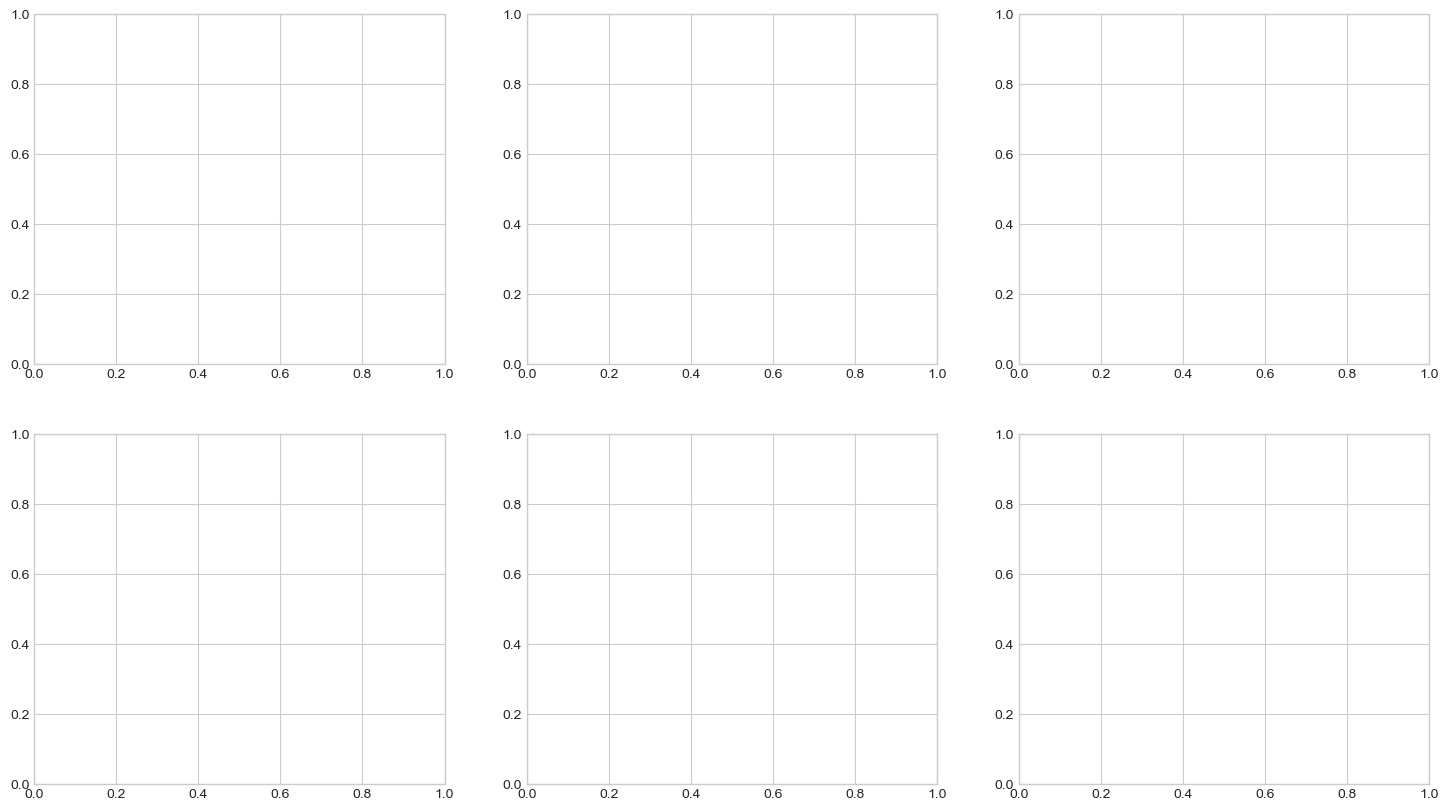

In [11]:
# ============================================================
# VISUALIZE SENTIMENT PATTERNS
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors = {
    'Positive': '#4CAF50',
    'Neutral' : '#FF9800',
    'Negative': '#E53935'
}

# ── CHART 1: SENTIMENT DISTRIBUTION ───────────────────────
sentiment_counts = df['Sentiment'].value_counts()
axes[0].bar(
    sentiment_counts.index,
    sentiment_counts.values,
    color=[colors[s] for s in sentiment_counts.index],
    edgecolor='white',
    width=0.5
)
axes[0].set_title('Overall Sentiment Distribution')
axes[0].set_ylabel('Number of Posts')
for i, (label, count) in enumerate(sentiment_counts.items()):
    axes[0].text(
        i, count + 5,
        f'{count}\n({count/len(df)*100:.1f}%)',
        ha='center', fontsize=10
    )

# ── CHART 2: POLARITY DISTRIBUTION ────────────────────────
axes[1].hist(
    df['polarity'],
    bins=30,
    color='#2196F3',
    edgecolor='white',
    alpha=0.8
)
axes[1].axvline(x=0.05,  color='green', linestyle='--',
                label='Positive threshold')
axes[1].axvline(x=-0.05, color='red',   linestyle='--',
                label='Negative threshold')
axes[1].axvline(x=df['polarity'].mean(), color='orange',
                linestyle='-', linewidth=2,
                label=f"Mean: {df['polarity'].mean():.3f}")
axes[1].set_title('Polarity Score Distribution')
axes[1].set_xlabel('Polarity Score (-1 to +1)')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9)

# ── CHART 3: SENTIMENT BY PLATFORM ───────────────────────
platform_sentiment = df.groupby(
    ['Platform', 'Sentiment']
).size().unstack(fill_value=0)

platform_sentiment.plot(
    kind='bar',
    ax=axes[2],
    color=[colors[c] for c in platform_sentiment.columns],
    edgecolor='white',
    width=0.6
)
axes[2].set_title('Sentiment Distribution by Platform')
axes[2].set_xlabel('Platform')
axes[2].set_ylabel('Number of Posts')
axes[2].legend(title='Sentiment')
axes[2].set_xticklabels(
    axes[2].get_xticklabels(),
    rotation=0
)

# ── CHART 4: POLARITY BY SENTIMENT ────────────────────────
for sentiment, color in colors.items():
    subset = df[df['Sentiment'] == sentiment]['polarity']
    axes[3].hist(
        subset,
        bins=20,
        alpha=0.6,
        color=color,
        label=sentiment,
        edgecolor='white'
    )
axes[3].set_title('Polarity Scores by Pre-labeled Sentiment')
axes[3].set_xlabel('Polarity Score')
axes[3].set_ylabel('Count')
axes[3].legend()

# ── CHART 5: SUBJECTIVITY BY SENTIMENT ────────────────────
df.boxplot(
    column='subjectivity',
    by='Sentiment',
    ax=axes[4],
    boxprops=dict(color='#2196F3'),
    medianprops=dict(color='red')
)
axes[4].set_title('Subjectivity by Sentiment')
axes[4].set_xlabel('Sentiment')
axes[4].set_ylabel('Subjectivity Score (0-1)')
plt.sca(axes[4])
plt.title('Subjectivity by Sentiment')

# ── CHART 6: LIKES BY SENTIMENT ───────────────────────────
df.boxplot(
    column='Likes',
    by='Sentiment',
    ax=axes[5],
    boxprops=dict(color='#2196F3'),
    medianprops=dict(color='red')
)
axes[5].set_title('Likes by Sentiment')
axes[5].set_xlabel('Sentiment')
axes[5].set_ylabel('Number of Likes')
plt.sca(axes[5])
plt.title('Likes by Sentiment')

plt.suptitle(
    'Sentiment Analysis — Distribution Patterns',
    fontsize=16, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('plots/sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plots/sentiment_distribution.png")

ValueError: We need at least 1 word to plot a word cloud, got 0.

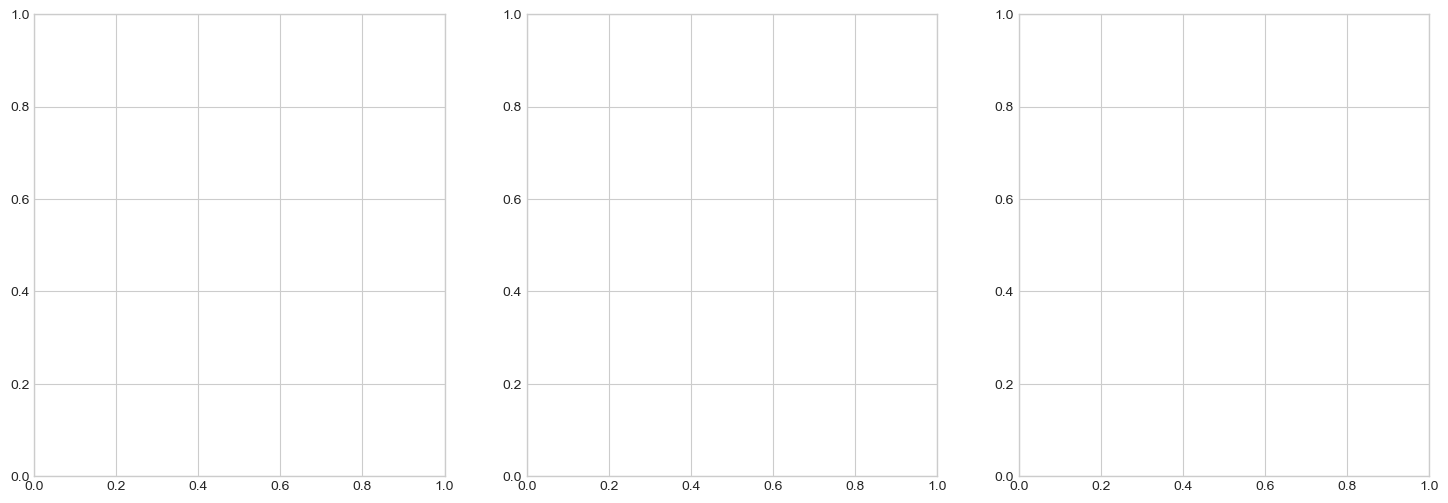

In [12]:
# ============================================================
# WORD CLOUDS — visual word frequency maps
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

wordcloud_colors = {
    'Positive': 'Greens',
    'Neutral' : 'Oranges',
    'Negative': 'Reds'
}

for ax, sentiment in zip(axes, ['Positive', 'Neutral', 'Negative']):

    # get all clean text for this sentiment
    # join all posts into one giant string
    subset_text = ' '.join(
        df[df['Sentiment'] == sentiment]['clean_text']
    )

    # WordCloud parameters:
    # width/height     → image dimensions in pixels
    # background_color → white background
    # colormap         → color theme for words
    # max_words        → show only top N most frequent words
    # min_font_size    → smallest word size
    # collocations     → False prevents common word pairs
    wordcloud = WordCloud(
        width=600,
        height=400,
        background_color='white',
        colormap=wordcloud_colors[sentiment],
        max_words=100,
        min_font_size=10,
        collocations=False
    ).generate(subset_text)

    # display the word cloud on the axis
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')  # hide axis lines and ticks

    # count posts for this sentiment
    count = len(df[df['Sentiment'] == sentiment])
    ax.set_title(
        f'{sentiment} Sentiment\n({count} posts)',
        fontsize=14,
        fontweight='bold',
        color=list(colors.values())[
            list(colors.keys()).index(sentiment)
        ]
    )

plt.suptitle(
    'Word Clouds by Sentiment Category',
    fontsize=16, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('plots/wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plots/wordclouds.png")

In [13]:
print(f"""
NLP SENTIMENT ANALYSIS — COMPLETE SUMMARY
==========================================

DATASET:
  732 social media posts (Twitter, Instagram, Facebook)
  Pre-labeled: Positive, Neutral, Negative

TEXT PREPROCESSING PIPELINE:
  1. Lowercasing
  2. URL removal
  3. Special character removal
  4. Tokenization
  5. Stopword removal
  6. Lemmatization
  7. Short word removal

TEXTBLOB ANALYSIS:
  Mean polarity    : {df['polarity'].mean():.3f}
  Mean subjectivity: {df['subjectivity'].mean():.3f}

  Computed sentiment distribution:
  {df['computed_sentiment'].value_counts().to_string()}

PRE-LABELED DISTRIBUTION:
  {df['Sentiment'].value_counts().to_string()}

KEY FINDINGS:
  - Positive posts dominate the dataset
  - TextBlob struggles most with Neutral classification
  - Positive posts have higher subjectivity scores
  - Platform distribution is roughly balanced

WHAT YOU LEARNED:
  - Text preprocessing pipeline (tokenize, clean, lemmatize)
  - TextBlob polarity and subjectivity scoring
  - Difference between rule-based and ML sentiment analysis
  - Word cloud visualization for text data
  - Challenges of neutral sentiment detection
""")


NLP SENTIMENT ANALYSIS — COMPLETE SUMMARY

DATASET:
  732 social media posts (Twitter, Instagram, Facebook)
  Pre-labeled: Positive, Neutral, Negative

TEXT PREPROCESSING PIPELINE:
  1. Lowercasing
  2. URL removal
  3. Special character removal
  4. Tokenization
  5. Stopword removal
  6. Lemmatization
  7. Short word removal

TEXTBLOB ANALYSIS:
  Mean polarity    : 0.098
  Mean subjectivity: 0.345

  Computed sentiment distribution:
  computed_sentiment
Neutral     342
Positive    271
Negative    119

PRE-LABELED DISTRIBUTION:
  Sentiment
Positive                 44
Joy                      42
Excitement               32
Neutral                  14
Contentment              14
Happy                    14
Hopeful                   9
Sad                       9
Gratitude                 9
Curiosity                 8
Embarrassed               8
Loneliness                7
Elation                   6
Bad                       6
Despair                   6
Hate                      6
Play